In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

BASE_DIR = r"E:\Rasengan\Cloud-Removal"

METADATA_DIR = os.path.join(BASE_DIR, "metadata")
PATCH_DIR = os.path.join(BASE_DIR, "data", "patches")

TEST_CSV = os.path.join(METADATA_DIR, "test.csv")

CHECKPOINT_PATH = os.path.join(
    BASE_DIR,
    "checkpoints",
    "unet_epoch_5.pth"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Test CSV:", TEST_CSV)
print("Checkpoint:", CHECKPOINT_PATH)

Device: cuda
Test CSV: E:\Rasengan\Cloud-Removal\metadata\test.csv
Checkpoint: E:\Rasengan\Cloud-Removal\checkpoints\unet_epoch_5.pth


In [2]:
class CloudRemovalDataset(Dataset):
    def __init__(self, csv_file, patch_dir):
        self.df = pd.read_csv(csv_file)
        self.patch_dir = patch_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        cloudy_path = os.path.join(
            self.patch_dir,
            row["source"],
            "cloudy",
            row["cloudy_filename"]
        )

        clear_path = os.path.join(
            self.patch_dir,
            row["source"],
            "non-cloudy",
            row["noncloudy_filename"]
        )

        cloudy = Image.open(cloudy_path).convert("RGB")
        clear = Image.open(clear_path).convert("RGB")

        cloudy = torch.from_numpy(
            np.array(cloudy)
        ).permute(2, 0, 1).float() / 255.0

        clear = torch.from_numpy(
            np.array(clear)
        ).permute(2, 0, 1).float() / 255.0

        return cloudy, clear


test_dataset = CloudRemovalDataset(
    TEST_CSV,
    PATCH_DIR
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test pairs:", len(test_dataset))
print("Test batches:", len(test_loader))

Test pairs: 25000
Test batches: 1563


In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 512)

        self.up4 = nn.ConvTranspose2d(512, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.output(d1))


model = UNet().to(device)

print("U-Net created successfully.")

U-Net created successfully.


In [4]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Model loaded successfully.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Training loss:", checkpoint["train_loss"])
print("Validation loss:", checkpoint["val_loss"])
print("Device:", device)

Model loaded successfully.
Checkpoint epoch: 5
Training loss: 0.032684995250668966
Validation loss: 0.02825096937674631
Device: cuda


In [5]:
cloudy, clear = next(iter(test_loader))

cloudy = cloudy.to(device)
clear = clear.to(device)

with torch.no_grad():
    output = model(cloudy)

print("Cloudy shape :", cloudy.shape)
print("Clear shape  :", clear.shape)
print("Output shape :", output.shape)
print("Output range :", output.min().item(), "to", output.max().item())

print("\n✓ Test batch prediction successful.")

Cloudy shape : torch.Size([16, 3, 256, 256])
Clear shape  : torch.Size([16, 3, 256, 256])
Output shape : torch.Size([16, 3, 256, 256])
Output range : 0.029634281992912292 to 0.25463080406188965

✓ Test batch prediction successful.


In [6]:
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

mae = F.l1_loss(output, clear).item()

mse = F.mse_loss(output, clear).item()
rmse = mse ** 0.5

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

psnr = psnr_metric(output, clear).item()
ssim = ssim_metric(output, clear).item()

output_spectral = output.permute(0, 2, 3, 1)
clear_spectral = clear.permute(0, 2, 3, 1)

dot_product = torch.sum(
    output_spectral * clear_spectral,
    dim=-1
)

output_norm = torch.linalg.vector_norm(
    output_spectral,
    dim=-1
)

clear_norm = torch.linalg.vector_norm(
    clear_spectral,
    dim=-1
)

cosine = dot_product / (
    output_norm * clear_norm + 1e-8
)

cosine = torch.clamp(cosine, -1.0, 1.0)

sam = torch.acos(cosine).mean().item()
sam_degrees = sam * 180 / torch.pi

print("=" * 50)
print("ONE BATCH METRICS")
print("=" * 50)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"PSNR : {psnr:.4f} dB")
print(f"SSIM : {ssim:.6f}")
print(f"SAM  : {sam_degrees:.4f} degrees")

ONE BATCH METRICS
MAE  : 0.049708
RMSE : 0.056590
PSNR : 24.9452 dB
SSIM : 0.822017
SAM  : 8.0144 degrees


In [7]:
import os
import glob
import torch

checkpoint_files = sorted(
    glob.glob(os.path.join(BASE_DIR, "checkpoints", "unet_epoch_*.pth"))
)

checkpoint_info = []

for path in checkpoint_files:
    checkpoint = torch.load(path, map_location="cpu")

    checkpoint_info.append({
        "epoch": checkpoint["epoch"],
        "train_loss": checkpoint["train_loss"],
        "val_loss": checkpoint["val_loss"],
        "path": path
    })

checkpoint_info = sorted(checkpoint_info, key=lambda x: x["val_loss"])

print("=" * 50)
print("U-NET CHECKPOINTS")
print("=" * 50)

for info in checkpoint_info:
    print(
        f"Epoch {info['epoch']} | "
        f"Train L1: {info['train_loss']:.6f} | "
        f"Val L1: {info['val_loss']:.6f}"
    )

best_checkpoint = checkpoint_info[0]

CHECKPOINT_PATH = best_checkpoint["path"]

print("\n" + "=" * 50)
print(f"BEST CHECKPOINT: EPOCH {best_checkpoint['epoch']}")
print(f"Validation L1: {best_checkpoint['val_loss']:.6f}")
print(f"Path: {CHECKPOINT_PATH}")
print("=" * 50)

U-NET CHECKPOINTS
Epoch 5 | Train L1: 0.032685 | Val L1: 0.028251
Epoch 2 | Train L1: 0.043470 | Val L1: 0.029429
Epoch 3 | Train L1: 0.037581 | Val L1: 0.029594
Epoch 4 | Train L1: 0.034599 | Val L1: 0.031152
Epoch 1 | Train L1: 0.039392 | Val L1: 0.031275

BEST CHECKPOINT: EPOCH 5
Validation L1: 0.028251
Path: E:\Rasengan\Cloud-Removal\checkpoints\unet_epoch_5.pth


In [8]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("=" * 50)
print("BEST U-NET MODEL LOADED")
print("=" * 50)
print(f"Epoch       : {checkpoint['epoch']}")
print(f"Train L1    : {checkpoint['train_loss']:.6f}")
print(f"Validation L1: {checkpoint['val_loss']:.6f}")
print(f"Device      : {device}")
print("=" * 50)

BEST U-NET MODEL LOADED
Epoch       : 5
Train L1    : 0.032685
Validation L1: 0.028251
Device      : cuda


In [9]:
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

total_abs_error = 0.0
total_squared_error = 0.0
total_pixels = 0

sam_sum = 0.0
sam_count = 0

model.eval()

with torch.no_grad():
    for batch_idx, (cloudy, clear) in enumerate(test_loader):

        cloudy = cloudy.to(device, non_blocking=True)
        clear = clear.to(device, non_blocking=True)

        output = model(cloudy)

        abs_error = torch.abs(output - clear)
        squared_error = (output - clear) ** 2

        total_abs_error += abs_error.sum().item()
        total_squared_error += squared_error.sum().item()
        total_pixels += output.numel()

        psnr_metric.update(output, clear)
        ssim_metric.update(output, clear)

        output_spectral = output.permute(0, 2, 3, 1)
        clear_spectral = clear.permute(0, 2, 3, 1)

        dot_product = torch.sum(
            output_spectral * clear_spectral,
            dim=-1
        )

        output_norm = torch.linalg.vector_norm(
            output_spectral,
            dim=-1
        )

        clear_norm = torch.linalg.vector_norm(
            clear_spectral,
            dim=-1
        )

        valid_mask = clear_norm > 1e-6

        cosine = dot_product / (
            output_norm * clear_norm + 1e-8
        )

        cosine = torch.clamp(cosine, -1.0, 1.0)

        sam_angles = torch.acos(cosine)

        sam_sum += sam_angles[valid_mask].sum().item()
        sam_count += valid_mask.sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Processed {(batch_idx + 1) * test_loader.batch_size:,} "
                f"/ {len(test_dataset):,} test pairs"
            )

mae = total_abs_error / total_pixels

mse = total_squared_error / total_pixels
rmse = mse ** 0.5

psnr = psnr_metric.compute().item()
ssim = ssim_metric.compute().item()

sam_radians = sam_sum / sam_count
sam_degrees = sam_radians * 180.0 / torch.pi

print("\n" + "=" * 55)
print("FINAL U-NET TEST RESULTS")
print("=" * 55)
print(f"Test pairs : {len(test_dataset):,}")
print(f"MAE        : {mae:.6f}")
print(f"RMSE       : {rmse:.6f}")
print(f"PSNR       : {psnr:.4f} dB")
print(f"SSIM       : {ssim:.6f}")
print(f"SAM        : {sam_degrees:.4f} degrees")
print("=" * 55)

Processed 1,600 / 25,000 test pairs
Processed 3,200 / 25,000 test pairs
Processed 4,800 / 25,000 test pairs
Processed 6,400 / 25,000 test pairs
Processed 8,000 / 25,000 test pairs
Processed 9,600 / 25,000 test pairs
Processed 11,200 / 25,000 test pairs
Processed 12,800 / 25,000 test pairs
Processed 14,400 / 25,000 test pairs
Processed 16,000 / 25,000 test pairs
Processed 17,600 / 25,000 test pairs
Processed 19,200 / 25,000 test pairs
Processed 20,800 / 25,000 test pairs
Processed 22,400 / 25,000 test pairs
Processed 24,000 / 25,000 test pairs

FINAL U-NET TEST RESULTS
Test pairs : 25,000
MAE        : 0.043772
RMSE       : 0.067446
PSNR       : 23.4209 dB
SSIM       : 0.808675
SAM        : 9.9696 degrees


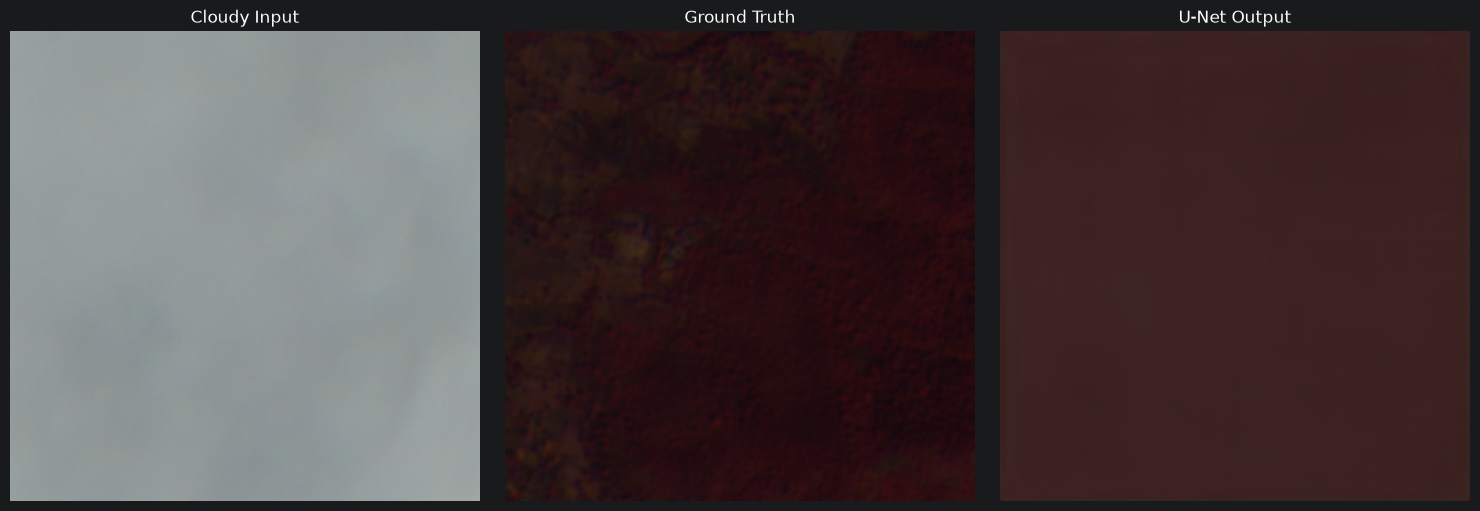

In [10]:
import matplotlib.pyplot as plt

cloudy, clear = next(iter(test_loader))

cloudy = cloudy.to(device)
clear = clear.to(device)

with torch.no_grad():
    output = model(cloudy)

cloudy_img = cloudy[0].cpu().permute(1, 2, 0).numpy()
clear_img = clear[0].cpu().permute(1, 2, 0).numpy()
output_img = output[0].cpu().permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cloudy_img)
axes[0].set_title("Cloudy Input")

axes[1].imshow(clear_img)
axes[1].set_title("Ground Truth")

axes[2].imshow(output_img)
axes[2].set_title("U-Net Output")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print("=" * 50)
print("IMAGE VALUE STATISTICS")
print("=" * 50)

for name, image in [
    ("Cloudy Input", cloudy_img),
    ("Ground Truth", clear_img),
    ("U-Net Output", output_img)
]:
    print(f"\n{name}")
    print(f"Min   : {image.min():.6f}")
    print(f"Max   : {image.max():.6f}")
    print(f"Mean  : {image.mean():.6f}")
    print(f"Std   : {image.std():.6f}")

IMAGE VALUE STATISTICS

Cloudy Input
Min   : 0.529412
Max   : 0.654902
Mean  : 0.596100
Std   : 0.020753

Ground Truth
Min   : 0.031373
Max   : 0.258824
Mean  : 0.091420
Std   : 0.044095

U-Net Output
Min   : 0.103595
Max   : 0.254631
Mean  : 0.167542
Std   : 0.048141


The interesting part is the standard deviation:

Ground truth: 0.0441
U-Net: 0.0481

So the U-Net is not simply outputting a constant image. It has spatial variation comparable to the ground truth.

The major problem is the brightness/intensity distribution: the output is shifted considerably above the target.

This is actually useful for your project because it shows exactly why we don't want to stop at a plain L1 U-Net. A pixel-wise L1 objective encourages a safe reconstruction, but it doesn't strongly enforce realistic high-frequency detail.

In [12]:
band_names = ["B4 (NIR)", "B3 (Red)", "B2 (Green)"]

print("=" * 65)
print("PER-BAND IMAGE STATISTICS")
print("=" * 65)

for i, band in enumerate(band_names):
    print(f"\n{band}")

    print(
        f"Cloudy : "
        f"min={cloudy_img[:, :, i].min():.4f}, "
        f"max={cloudy_img[:, :, i].max():.4f}, "
        f"mean={cloudy_img[:, :, i].mean():.4f}, "
        f"std={cloudy_img[:, :, i].std():.4f}"
    )

    print(
        f"Truth  : "
        f"min={clear_img[:, :, i].min():.4f}, "
        f"max={clear_img[:, :, i].max():.4f}, "
        f"mean={clear_img[:, :, i].mean():.4f}, "
        f"std={clear_img[:, :, i].std():.4f}"
    )

    print(
        f"U-Net  : "
        f"min={output_img[:, :, i].min():.4f}, "
        f"max={output_img[:, :, i].max():.4f}, "
        f"mean={output_img[:, :, i].mean():.4f}, "
        f"std={output_img[:, :, i].std():.4f}"
    )

PER-BAND IMAGE STATISTICS

B4 (NIR)
Cloudy : min=0.5294, max=0.6353, mean=0.5749, std=0.0151
Truth  : min=0.0706, max=0.2588, mean=0.1480, std=0.0225
U-Net  : min=0.1941, max=0.2546, mean=0.2354, std=0.0041

B3 (Red)
Cloudy : min=0.5686, max=0.6549, mean=0.6067, std=0.0145
Truth  : min=0.0314, max=0.1725, mean=0.0587, std=0.0194
U-Net  : min=0.1039, max=0.1518, mean=0.1350, std=0.0046

B2 (Green)
Cloudy : min=0.5686, max=0.6510, mean=0.6067, std=0.0134
Truth  : min=0.0471, max=0.1255, mean=0.0676, std=0.0108
U-Net  : min=0.1036, max=0.1480, mean=0.1323, std=0.0031


producing much smoother images

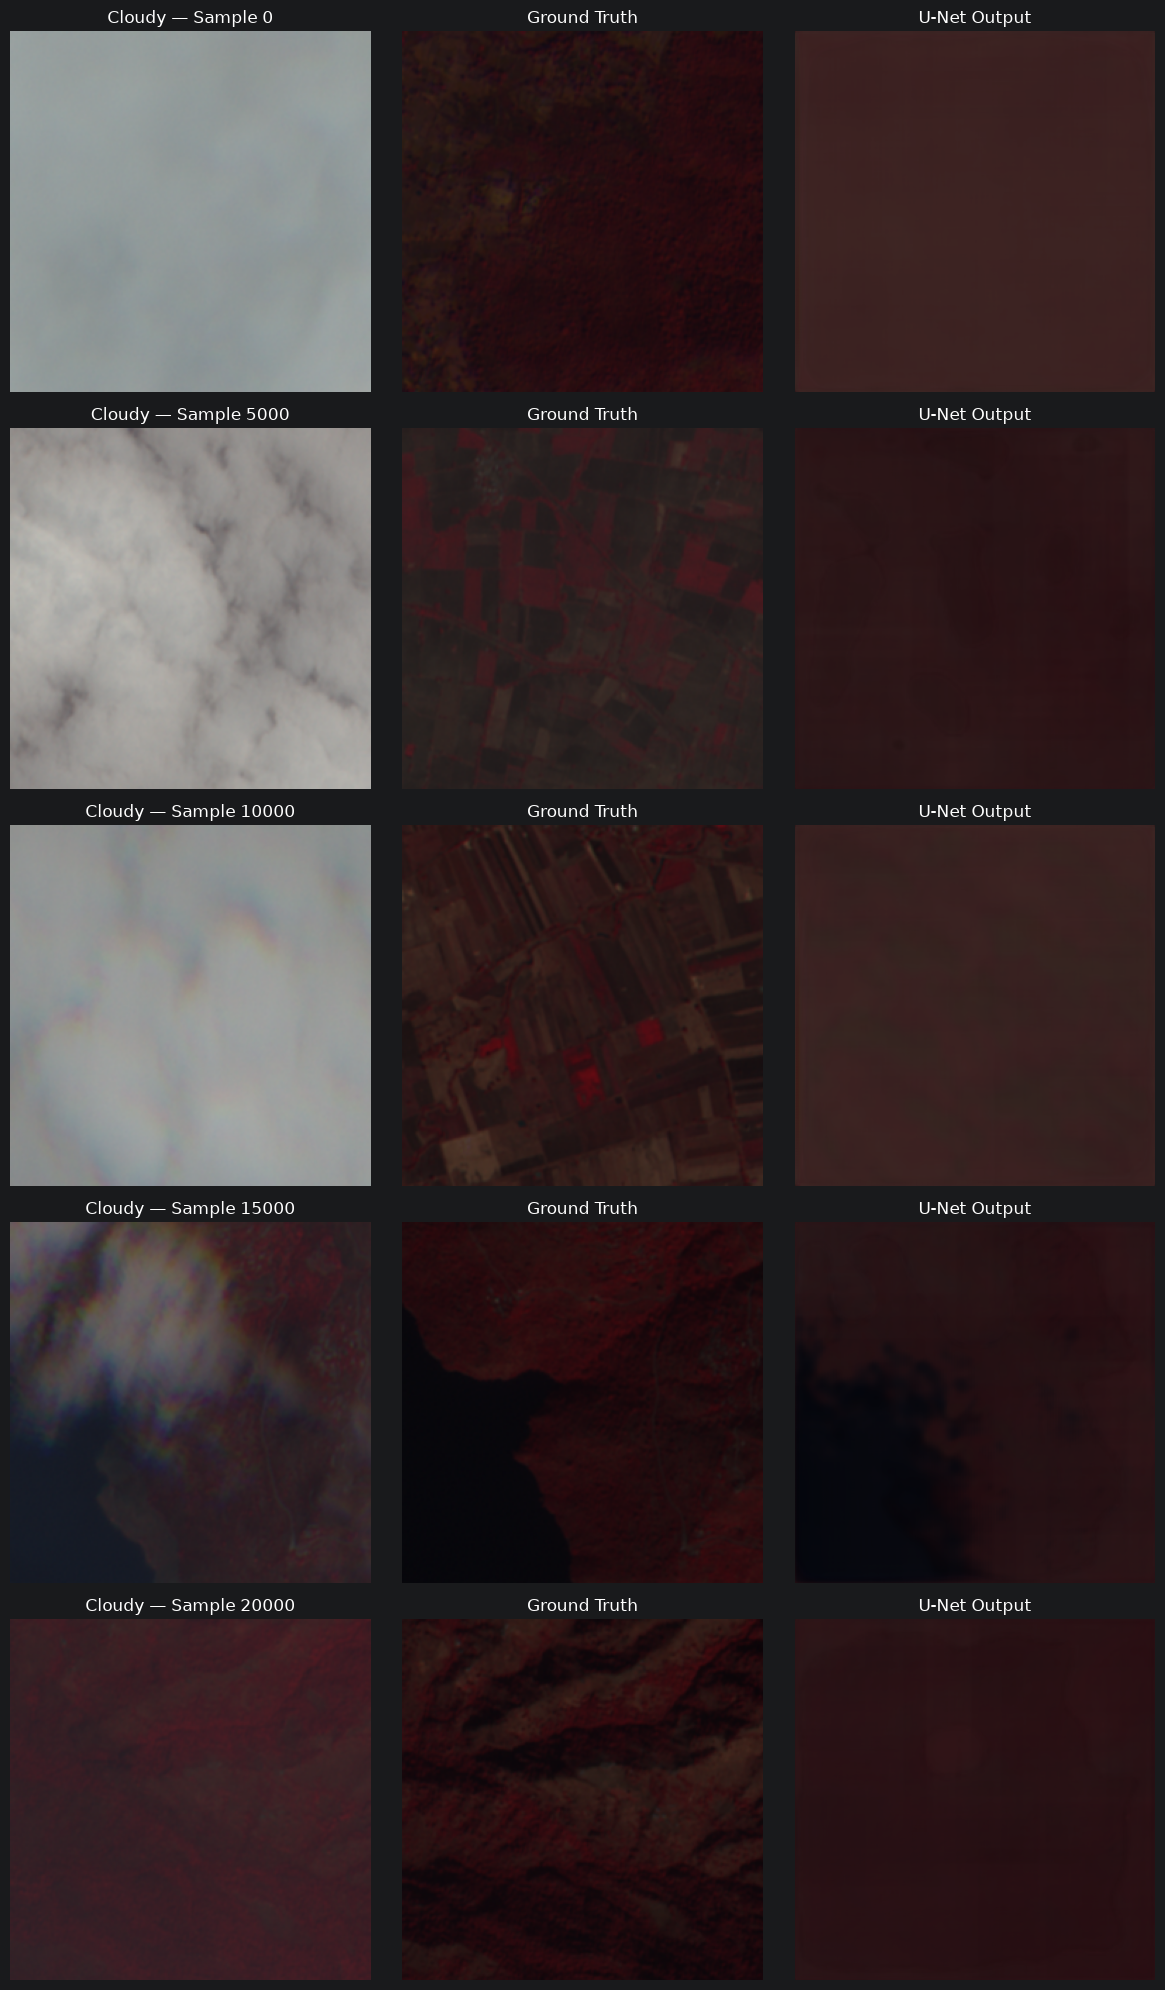

In [13]:
import matplotlib.pyplot as plt

sample_indices = [0, 5000, 10000, 15000, 20000]

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for row_idx, sample_idx in enumerate(sample_indices):

    cloudy, clear = test_dataset[sample_idx]

    cloudy_input = cloudy.unsqueeze(0).to(device)
    clear_input = clear.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(cloudy_input)

    cloudy_img = cloudy.permute(1, 2, 0).numpy()
    clear_img = clear.permute(1, 2, 0).numpy()
    output_img = prediction[0].cpu().permute(1, 2, 0).numpy()

    axes[row_idx, 0].imshow(cloudy_img)
    axes[row_idx, 0].set_title(f"Cloudy — Sample {sample_idx}")

    axes[row_idx, 1].imshow(clear_img)
    axes[row_idx, 1].set_title("Ground Truth")

    axes[row_idx, 2].imshow(output_img)
    axes[row_idx, 2].set_title("U-Net Output")

    for col_idx in range(3):
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

heavily smoothing the scene and failing to recover fine spatial details.

# Stage 1 — U-Net Baseline Results

## 1. Baseline Overview

The first stage of the Cloud Removal project uses a standard **U-Net** architecture for supervised image-to-image reconstruction.

The objective is to reconstruct a cloud-free LISS-IV false-color composite from a cloudy LISS-IV input.

- **Input:** Cloudy LISS-IV FCC
- **Target:** Corresponding non-cloudy LISS-IV FCC
- **Bands:** B4 (NIR), B3 (Red), B2 (Green)
- **Patch size:** 256 × 256 pixels
- **Loss:** L1 Loss
- **Optimizer:** Adam
- **Learning rate:** 2 × 10⁻⁴
- **Training epochs:** 5

---

## 2. Dataset

The final dataset contains:

**235,001 paired cloudy/non-cloudy patches**

The dataset was divided at the scene/group level to prevent spatial leakage from overlapping patches belonging to the same scene.

| Split | Pairs | Groups |
|---|---:|---:|
| Train | 185,001 | 38 |
| Validation | 25,000 | 5 |
| Test | 25,000 | 5 |
| **Total** | **235,001** | **48** |

The test set was kept completely unseen during training and model selection.

---

## 3. Best Checkpoint Selection

Five trained checkpoints were compared using validation L1 loss.

| Epoch | Train L1 | Validation L1 |
|---:|---:|---:|
| 1 | 0.039392 | 0.031275 |
| 2 | 0.043470 | 0.029429 |
| 3 | 0.037581 | 0.029594 |
| 4 | 0.034599 | 0.031152 |
| **5** | **0.032685** | **0.028251** |

**Epoch 5** was selected as the best checkpoint because it achieved the lowest validation L1 loss of **0.028251**.

---

## 4. Evaluation Metrics

Five metrics were used to evaluate the cloud-removal reconstruction.

| Metric | Objective |
|---|---|
| **MAE ↓** | Lower is better |
| **RMSE ↓** | Lower is better |
| **PSNR ↑** | Higher is better |
| **SSIM ↑** | Higher is better |
| **SAM ↓** | Lower is better |

### Metric significance

- **MAE:** Measures average absolute pixel reconstruction error.
- **RMSE:** Measures reconstruction error while giving greater weight to larger errors.
- **PSNR:** Measures pixel-level reconstruction quality.
- **SSIM:** Measures structural similarity between reconstructed and reference images.
- **SAM:** Measures the spectral-angle difference between predicted and reference LISS-IV spectral vectors `[B4, B3, B2]`.

SAM is particularly important because the imagery is multispectral LISS-IV FCC rather than conventional RGB imagery.

---

## 5. Final Test Results

The selected Epoch 5 U-Net was evaluated on the complete **25,000-pair test set**.

| Metric | U-Net Result |
|---|---:|
| **MAE ↓** | **0.043772** |
| **RMSE ↓** | **0.067446** |
| **PSNR ↑** | **23.4209 dB** |
| **SSIM ↑** | **0.808675** |
| **SAM ↓** | **9.9696°** |

These values represent the official **Stage 1 U-Net baseline**.

---

## 6. Qualitative Evaluation

Visual comparisons were performed using:

1. Cloudy input
2. Ground-truth non-cloudy image
3. U-Net reconstruction

Multiple test samples were inspected.

The U-Net successfully transforms the cloudy input toward the appearance of the clear target. However, the reconstructed images are noticeably **smoother than the ground-truth images**.

Fine spatial structures and local variations are not recovered strongly.

Therefore, the baseline demonstrates that the model has learned the general cloudy-to-clear mapping, but its reconstruction quality is not yet sufficient for high-fidelity cloud removal.

---

## 7. Per-Band Analysis

A representative test sample was examined separately for the three LISS-IV bands.

| Band | Ground Truth Std | U-Net Output Std |
|---|---:|---:|
| **B4 (NIR)** | 0.0225 | 0.0041 |
| **B3 (Red)** | 0.0194 | 0.0046 |
| **B2 (Green)** | 0.0108 | 0.0031 |

The considerably lower variation in the U-Net output indicates that the reconstruction is substantially smoother than the reference image.

Representative mean values were:

| Band | Ground Truth Mean | U-Net Mean |
|---|---:|---:|
| **B4 (NIR)** | 0.1480 | 0.2354 |
| **B3 (Red)** | 0.0587 | 0.1350 |
| **B2 (Green)** | 0.0676 | 0.1323 |

This shows that the baseline does not reproduce the target radiometric distribution perfectly.

---

## 8. Baseline Assessment

The U-Net baseline provides a useful reference for the remaining experiments.

### Strengths

- Successfully learns the cloudy-to-clear mapping.
- Produces structurally recognizable reconstructions.
- Achieves **SSIM = 0.808675** on the complete test set.
- Provides a reproducible quantitative baseline using five evaluation metrics.

### Limitations

- Reconstructions are overly smooth.
- Fine spatial details are lost.
- Spectral/spatial variation is lower than in the ground truth.
- The model does not yet achieve the desired high-fidelity cloud reconstruction.

The limitations motivate the use of stronger image-to-image architectures in the subsequent stages.

---

## 9. Stage 1 Conclusion

The **U-Net + L1** model is established as the baseline for the Cloud Removal project.

### Official Baseline

**MAE:** 0.043772
**RMSE:** 0.067446
**PSNR:** 23.4209 dB
**SSIM:** 0.808675
**SAM:** 9.9696°

The baseline is considered **promising but not fully satisfactory**, particularly because of the loss of fine spatial detail and the smoother spectral reconstruction observed during qualitative analysis.

The same test set and the same five metrics will be used for the subsequent models to ensure a fair comparison.

---

## 10. Next Stage

### Stage 2 — Image-to-Image Model

The next experiment will use an established image-to-image reconstruction architecture.

The model will be trained and evaluated using:

- The same training/validation/test split
- The same LISS-IV input and target representation
- The same five evaluation metrics

The objective is to determine whether Stage 2 can improve upon the U-Net baseline before introducing adversarial training in Stage 3.

### Planned progression

**Stage 1:** U-Net + L1 → **Completed**

**Stage 2:** Established image-to-image architecture → **Next**

**Stage 3:** U-Net + PatchGAN / Pix2Pix-style GAN → **Final**